In [1]:
import sys
import os

model_upgrading_path = os.path.join("..","src")
sys.path.append(model_upgrading_path)

In [2]:
# My Modeul
from my_package.data.select_dataset_all import get_all_dataframe_from_database
#from my_package.model.automl import automl
from my_package.data.select_dataset_fluid import get_dataframe_from_database_fluid
from my_package.data.select_dataset import get_dataframe_from_database
from my_package.model import health_model

# External Package
import pandas as pd

# visualization
import matplotlib.pyplot as plt

# Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, plot_importance
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

<span style="color: blue; font-size: 15px; font-weight: bold; background-color: #f0f0f0; padding: 5px; border-radius: 5px;">
   함수
</span>

In [3]:
def all_zero(row):
    return row.sum() == 0

In [4]:
def create_learning_data(data):
    
    # 변수 선택
    data = data[['CSU', 'STS', 'FTS', 'FMU', 'CURRENT','TRO_MIN','TRO_MEAN','TRO_MAX', 'TRO_DIFF_MIN','TRO_DIFF_MEAN','TRO_DIFF_MAX','TRO_NEG_COUNT','PEAK_VALLEY_INDICES_MIN','PEAK_VALLEY_INDICES_MEAN',
                 'PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION','RE_CROSS_CORRELATION_COUNT','STEEP_LABEL', 'SLOWLY_LABEL', 'OUT_OF_WATER_STEEP', 'HUNTING','TIME_OFFSET']]
    
    # 정상 / 오류 분류
    data['classification'] = data[['STEEP_LABEL', 'SLOWLY_LABEL', 'OUT_OF_WATER_STEEP', 'HUNTING','TIME_OFFSET']].apply(all_zero, axis=1)
    
    # 인덱스 설정
    data = data.set_index(['CSU', 'STS', 'FTS', 'FMU', 'CURRENT','TRO_MIN','TRO_MEAN','TRO_MAX', 'TRO_DIFF_MIN','TRO_DIFF_MEAN','TRO_DIFF_MAX','TRO_NEG_COUNT','PEAK_VALLEY_INDICES_MIN','PEAK_VALLEY_INDICES_MEAN',
                           'PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION','RE_CROSS_CORRELATION_COUNT','classification'])
    
    # stack 활용 데이터 쌓기
    data = data.stack().to_frame()
    
    # 인덱스 리셋
    data = data.reset_index()
    
    # 컬럼 재 설정
    data.columns =['CSU', 'STS', 'FTS', 'FMU', 'CURRENT','TRO_MIN','TRO_MEAN','TRO_MAX', 'TRO_DIFF_MIN','TRO_DIFF_MEAN','TRO_DIFF_MAX','TRO_NEG_COUNT','PEAK_VALLEY_INDICES_MIN','PEAK_VALLEY_INDICES_MEAN',
                   'PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION','RE_CROSS_CORRELATION_COUNT','classification','label_name','exist']
    
    # 'classification'이 False인 행들 중에서 'exist'가 0인 행들만 필터링
    to_delete = (data['classification'] == False) & (data['exist'] == 0)
    
    # 해당 행들을 삭제
    df_cleaned = data[~to_delete]
    
    # 라벨 이름 설정
    true_index=  df_cleaned[df_cleaned['classification']==True].index
    df_cleaned.loc[true_index,'label_name'] = 'Normal' 
    
    # 삭제 조건: subset 리스트의 컬럼들이 모두 동일한 값을 가질 때 
    subset = ['CSU','STS','FTS','FMU','CURRENT','TRO_MIN','TRO_MEAN','TRO_MAX', 'TRO_DIFF_MIN','TRO_DIFF_MEAN','TRO_DIFF_MAX','TRO_NEG_COUNT','PEAK_VALLEY_INDICES_MIN','PEAK_VALLEY_INDICES_MEAN','PEAK_VALLEY_INDICES_MAX', 
              'CROSS_CORRELATION', 'RE_CROSS_CORRELATION','RE_CROSS_CORRELATION_COUNT']
    
    # subset에 지정된 컬럼들의 값이 모두 동일한 중복된 행들을 삭제
    df_cleaned = df_cleaned.drop_duplicates(subset=subset)
    
    # 라벨 인코딩
    label_encoding = LabelEncoder() 
    df_cleaned['label'] = label_encoding.fit_transform(df_cleaned['label_name'])
    
    # 컬럼 선택
    fit_data = df_cleaned[['CSU','STS','FTS','FMU','CURRENT','TRO_MIN','TRO_MEAN','TRO_MAX', 'TRO_DIFF_MIN','TRO_DIFF_MEAN','TRO_DIFF_MAX','TRO_NEG_COUNT','PEAK_VALLEY_INDICES_MIN','PEAK_VALLEY_INDICES_MEAN','PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION','RE_CROSS_CORRELATION_COUNT','label_name','label']]
   
    
    return fit_data 

In [5]:
def train_xgboost_multiple_model(data):
    
    """
    불균형 데이터셋에서 XGBoost 모델을 사용하여 불량 탐지를 수행하는 함수입니다.

    Parameters:
    - X: Feature 데이터 (DataFrame 또는 numpy array)
    - y: Label 데이터 (불량 라벨, Series 또는 numpy array)

    Returns:
    - model: 훈련된 XGBoost 모델
    - evaluation: 모델 평가 결과 (dict 형식)
    """
    

    # 1. 데이터셋 로드
    X = data.drop(columns = ['label_name','label']).values  # 특징 (features)
    y = data['label'].values.ravel()  # 레이블 (labels)

    # 2. 학습 데이터와 테스트 데이터로 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 클래스 가중치 계산
    classes = sorted(set(y))
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    
  # XGBoost 모델 설정
    model = xgb.XGBClassifier(
        objective='multi:softmax', # 다중 클래스 분류 문제
        num_class=len(classes),  # 클래스 개수
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        eval_metric='mlogloss',  # 다중 클래스 로그 손실
        scale_pos_weight=class_weights,
        use_label_encoder=False,
        random_state=42
    )
    # 4. 모델 학습
    model.fit(X_train, y_train)

    # 5. 예측 수행
    y_pred = model.predict(X_test)

    evaluation = {
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    }
    

    print(f"evaluation: {evaluation}")

In [6]:
def train_xgboost_model(data):
    """
    불균형 데이터셋에서 XGBoost 모델을 사용하여 불량 탐지를 수행하는 함수입니다.

    Parameters:
    - data: DataFrame, label 컬럼을 포함한 전체 데이터

    Returns:
    - model: 훈련된 XGBoost 모델
    - evaluation: 모델 평가 결과 (dict 형식)
    """

    # 1. 데이터셋 로드
    X = data.drop(columns=['label_name', 'label']).values  # 특징 (features)
    y = data['label'].values.ravel()  # 레이블 (labels)

    # 2. 학습 데이터와 테스트 데이터로 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 클래스 가중치 계산
    classes = sorted(set(y))
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    # XGBoost 모델 설정 (이진 분류)
    model = xgb.XGBClassifier(
        objective='binary:logistic',  # 이진 분류 문제
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        eval_metric='logloss',  # 이진 분류 로그 손실
        scale_pos_weight=class_weights[1],  # 불균형 데이터 가중치 조정
        use_label_encoder=False,
        random_state=42
    )

    # 4. 모델 학습
    model.fit(X_train, y_train)

    # 5. 예측 수행
    y_pred = model.predict(X_test)

    # 평가 결과
    evaluation = {
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    }
    
    print(f"evaluation: {evaluation}")

In [7]:
def train_xgboost_simple_model(data):
    """
    불균형 데이터셋에서 XGBoost 모델을 사용하여 불량 탐지를 수행하는 함수입니다.

    Parameters:
    - data: DataFrame, label 컬럼을 포함한 전체 데이터

    Returns:
    - model: 훈련된 XGBoost 모델
    - evaluation: 모델 평가 결과 (dict 형식)
    """

    # 1. 데이터셋 로드
    X = data.drop(columns=['label']).values  # 특징 (features)
    y = data['label'].values.ravel()  # 레이블 (labels)

    # 2. 학습 데이터와 테스트 데이터로 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    X_train = X_train[:,:-1]
    
    label_name = X_test[:,-1]
    X_test = X_test[:,:-1]
    
    # XGBoost 분류기 모델 생성
    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

    # 모델 학습
    model.fit(X_train, y_train)

    # 예측 수행
    y_pred = model.predict(X_test)

    # 모델 평가
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # 상세 평가 지표 출력
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    X_test = pd.DataFrame(X_test,columns = data.drop(columns=['label_name', 'label']).columns)
    X_test['Actual'] = y_test
    X_test['Pred'] = y_pred
    X_test['label_name'] = label_name
    
    return model,data.drop(columns=['label_name', 'label']).columns, X_test

In [8]:
# XGBoost 피처 중요도 시각화 함수
def plot_feature_importance(model, feature_names):
    """
    XGBoost 모델의 피처 중요도를 시각화하는 함수.

    Parameters:
    - model: 학습된 XGBoost 모델
    - feature_names: 피처 이름 리스트
    """
    # 피처 중요도 추출
    importance = model.feature_importances_
    
    # 중요도와 피처 이름을 데이터프레임으로 변환
    features_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)
    
    # 중요도 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.title('Feature Importance')
    plt.gca().invert_yaxis()  # 피처 중요도가 높은 순으로 표시
    plt.show()

In [9]:
def preprocessing_label_col(df):
    df['label'] = df['label'].apply(lambda x: 1 if x == 1 else 0)
    
    # 데이터 라벨 역변환
    df['label'] = df['label'].apply(lambda x: 0 if x == 1 else 1)
    
    df.dropna(inplace=True)

    return df

<span style="color: blue; font-size: 15px; font-weight: bold; background-color: #f0f0f0; padding: 5px; border-radius: 5px;">
   모델 학습
</span>

In [10]:
# goals: 데이터 로드

tro_group = get_all_dataframe_from_database('tc_ai_fault_group','ecs_test')
print(f" 원본 데이터 개수 : {len(tro_group)}")

 원본 데이터 개수 : 5524


In [13]:
cleaned_df.columns

Index(['CSU', 'STS', 'FTS', 'FMU', 'CURRENT', 'TRO_MIN', 'TRO_MEAN', 'TRO_MAX',
       'TRO_DIFF_MIN', 'TRO_DIFF_MEAN', 'TRO_DIFF_MAX', 'TRO_NEG_COUNT',
       'PEAK_VALLEY_INDICES_MIN', 'PEAK_VALLEY_INDICES_MEAN',
       'PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION',
       'RE_CROSS_CORRELATION_COUNT', 'label_name', 'label'],
      dtype='object')

In [12]:
cleaned_df[['CSU', 'STS', 'FTS', 'FMU', 'CURRENT', 'TRO_MIN', 'TRO_MEAN']]

,CSU,STS,FTS,FMU,CURRENT,TRO_MIN,TRO_MEAN,TRO_MAX,TRO_DIFF_MIN,TRO_DIFF_MEAN,TRO_DIFF_MAX,TRO_NEG_COUNT,PEAK_VALLEY_INDICES_MIN,PEAK_VALLEY_INDICES_MEAN,PEAK_VALLEY_INDICES_MAX,CROSS_CORRELATION,RE_CROSS_CORRELATION,RE_CROSS_CORRELATION_COUNT,label_name,label
4,24.300744,0.000000,38.880579,1073.205868,8001.487603,2.85,6.517769,9.66,-4.63,0.072397,3.90,2,0,0.049587,1,3.367359,1746.888815,4,TIME_OFFSET,1
5,22.901806,0.000000,42.500881,775.484537,4628.449339,0.00,8.815022,9.96,-1.58,0.043172,2.79,1,0,0.017621,1,6.317808,5140.282792,1,Normal,0
14,23.233550,0.000000,37.285976,881.560296,6674.230769,1.40,6.550828,9.91,-2.05,0.054083,3.48,2,0,0.053254,1,3.039436,2712.280610,7,TIME_OFFSET,1
19,23.999179,0.000000,37.719254,968.061866,7165.805970,1.44,6.355746,9.98,-1.92,0.033657,3.94,2,0,0.052239,1,3.534500,2045.962574,5,TIME_OFFSET,1
23,22.688736,0.000000,40.579011,824.495220,6567.862637,0.00,6.772198,9.93,-2.25,0.035495,3.27,2,0,0.054945,1,3.617816,2935.801750,8,HUNTING,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27585,30.266207,22.378473,29.636749,304.921133,995.073892,0.00,1.704631,8.21,-6.88,-0.006847,6.81,1,0,0.009852,1,-2.054541,435.029883,0,STEEP_LABEL,1
27595,30.073387,21.368656,29.138548,303.528978,993.838710,0.00,1.721667,3.11,-1.24,-0.014677,0.15,0,0,0.000000,0,-3.144423,933.313615,0,Normal,0
27600,30.074032,21.373817,29.145430,302.170054,994.623656,0.00,1.585000,2.60,-1.15,-0.011290,0.30,0,0,0.000000,0,-3.123303,920.627047,0,Normal,0
27610,34.214932,9.665000,14.058493,304.510753,999.239726,0.00,4.013425,4.23,-3.88,-0.013904,2.14,1,0,0.006849,1,-0.366170,78.421328,9,Normal,0


In [17]:
# goals: 함수 적용

# 1. 데이터 생성 함수 적용
cleaned_df = create_learning_data(tro_group)

# 2. 데이터 정제 함수 적용
cleaned_df = preprocessing_label_col(cleaned_df)
print(f"데이터 개수 : {len(cleaned_df)}")

# 3. 변수 선택
#cleaned_df = cleaned_df[['TRO_DIFF_MIN','PEAK_VALLEY_INDICES_MEAN','RE_CROSS_CORRELATION_COUNT','TRO_DIFF_MIN','RE_CROSS_CORRELATION','TRO_MEAN','TRO_MAX','TRO_NEG_COUNT','label_name','label']]

# 4. 모델 학습 함수 적용
#automl('label',cleaned_df.drop(columns='label_name'))
model,feature_names,X_test = train_xgboost_simple_model(cleaned_df)

데이터 개수 : 3874
Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       828
           1       0.96      0.97      0.96       335

    accuracy                           0.98      1163
   macro avg       0.97      0.98      0.97      1163
weighted avg       0.98      0.98      0.98      1163


Confusion Matrix:
[[814  14]
 [ 11 324]]


C:\Users\pc021\AppData\Local\Temp\ipykernel_13268\2739230599.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['classification'] = data[['STEEP_LABEL', 'SLOWLY_LABEL', 'OUT_OF_WATER_STEEP', 'HUNTING','TIME_OFFSET']].apply(all_zero, axis=1)
C:\Users\pc021\.pyenv\pyenv-win\versions\3.8.10\lib\site-packages\xgboost\core.py:158: UserWarning: [14:11:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [31]:
feature_names

Index(['CSU', 'STS', 'FTS', 'FMU', 'CURRENT', 'TRO_MIN', 'TRO_MEAN', 'TRO_MAX',
       'TRO_DIFF_MIN', 'TRO_DIFF_MEAN', 'TRO_DIFF_MAX', 'TRO_NEG_COUNT',
       'PEAK_VALLEY_INDICES_MIN', 'PEAK_VALLEY_INDICES_MEAN',
       'PEAK_VALLEY_INDICES_MAX', 'CROSS_CORRELATION', 'RE_CROSS_CORRELATION',
       'RE_CROSS_CORRELATION_COUNT'],
      dtype='object')

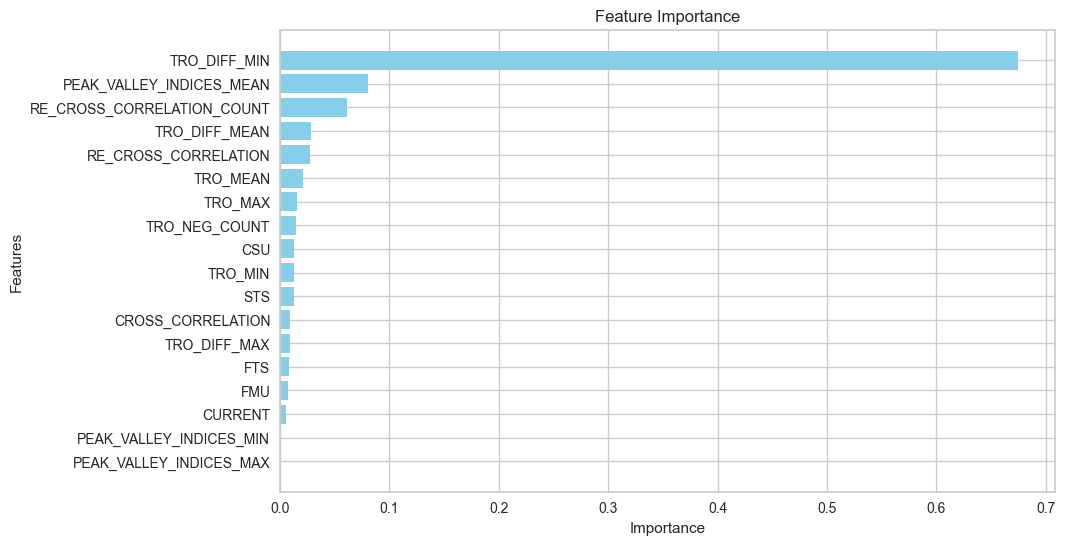

In [13]:
plot_feature_importance(model,feature_names)

<span style="color: blue; font-size: 15px; font-weight: bold; background-color: #f0f0f0; padding: 5px; border-radius: 5px;">
   탐색적 데이터 분석
</span>

In [12]:
# goals: 옵션 설정

# 디스 플레이 설정
pd.set_option('display.max_rows',200)

# 배 데이터 로드
ship_info = get_all_dataframe_from_database('shipinfo','ecs_dat1')

In [13]:
# goals: 특정 배 찾기
ship_info[ship_info['ship_id']=='T121129-17201'] 

,ship_id,ship_name,hull_no,imo_no,client_id,client_name,client_nat,yard_id,yard_name,yard_nat,...,ordgb,last_receive_date,ddjanm,temdate,insdate,hmi_version,manual,outdt,eddjanm,jgmss
108,T121129-17201,BUBBA BOOSH,N1711,9674218,B1192,Niovis Shipping Co. S.A.,Greece,B0044,"Kawasaki Heavy Industries, Ltd.",Japan,...,신조,2023-05-16 23:42:59,유경민,20230219,2023-04-04 17:13:59,2.0,0.0,,Dave,2.0


In [54]:
#sensor = get_dataframe_from_database_fluid('tc_ai_fault_label','T121129-17201',15,0)
#sensor = get_dataframe_from_database('T121129-17201',15,0)

X_test[X_test['Actual']==X_test['Pred']]

,CSU,STS,FTS,FMU,CURRENT,TRO_MIN,TRO_MEAN,TRO_MAX,TRO_DIFF_MIN,TRO_DIFF_MEAN,...,TRO_NEG_COUNT,PEAK_VALLEY_INDICES_MIN,PEAK_VALLEY_INDICES_MEAN,PEAK_VALLEY_INDICES_MAX,CROSS_CORRELATION,RE_CROSS_CORRELATION,RE_CROSS_CORRELATION_COUNT,Actual,Pred,label_name
0,41.75042,34.614706,0.0,1759.012269,15663.268908,0.0,5.196807,6.24,-4.88,0.043782,...,1,0,0.016807,1,0.421528,149.354328,1,0,0,Normal
1,36.475545,26.828273,29.440515,382.106364,2904.821212,0.0,7.005576,11.66,-7.3,0.022152,...,1,0,0.036364,1,4.830785,4290.436059,1,1,1,OUT_OF_WATER_STEEP
2,47.351821,0.0,0.0,730.676277,2951.535326,0.0,4.108696,4.77,-4.68,0.0,...,1,0,0.002717,1,4.317755,8192.697837,2,0,0,Normal
3,25.777343,15.378514,18.649336,813.601346,6107.769231,0.0,6.914703,9.01,-6.83,-0.001031,...,1,0,0.020979,1,-5.359071,8332.725284,2,1,1,OUT_OF_WATER_STEEP
4,39.3026,29.43795,32.476671,1727.049986,8759.536451,0.0,6.927538,8.33,-4.14,0.003906,...,1,0,0.002751,1,-7.857375,22783.641929,0,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,37.566957,34.328509,41.521553,859.640171,7795.298137,0.0,2.427065,4.09,-2.25,0.006351,...,1,0,0.003106,1,-11.928802,50354.210452,1,0,0,Normal
578,24.228372,10.395953,35.629674,1093.519349,6517.051163,5.76,7.703488,7.86,-0.24,0.009442,...,0,0,0.0,0,0.699612,66.642625,1,0,0,Normal
579,24.47144,10.823786,35.203827,743.235309,4416.744856,7.61,7.794568,7.95,-0.19,0.000206,...,0,0,0.0,0,5.810932,4221.841437,0,0,0,Normal
580,30.154367,20.245696,28.47038,697.736962,4158.240506,4.94,6.613544,6.86,-1.84,0.031266,...,1,0,0.0,0,4.584407,1877.094805,2,0,0,Normal


In [12]:
### analysis content

# Confusion Matrix: len: 2077 
#[[410  25]
# [ 38 151]]

#Accuracy: 0.90

#Classification Report:
#              precision    recall  f1-score   support

#           0       0.92      0.94      0.93       435
#           1       0.86      0.80      0.83       189

#    accuracy                           0.90       624
#   macro avg       0.89      0.87      0.88       624
#weighted avg       0.90      0.90      0.90       624


#Confusion Matrix:
#[[416  10]
# [  5 151]]

#Accuracy: 0.97

#Classification Report:
#              precision    recall  f1-score   support

#           0       0.99      0.98      0.98       426
#           1       0.94      0.97      0.95       156

#    accuracy                           0.97       582
#   macro avg       0.96      0.97      0.97       582
# weighted avg       0.97      0.97      0.97       582

In [19]:
health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\tro_model")

모델이 C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\tro_model에 성공적으로 저장되었습니다.
